In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
documents = [
    "Machine learning is a field of artificial intelligence that focuses on training models.",
    "Deep learning is a subset of machine learning that uses neural networks.",
    "Natural language processing helps computers understand human language."
]

summaries = [
    "ML trains models",
    "Deep learning uses neural networks",
    "NLP understands language"
]

In [3]:
def build_vocab(sentences):
    vocab = {"<pad>":0, "<unk>":1}
    idx = 2
    
    for sent in sentences:
        for word in sent.lower().split():
            if word not in vocab:
                vocab[word] = idx
                idx += 1
    return vocab

vocab = build_vocab(documents + summaries)

In [4]:
def encode(sentence, vocab, max_len=10):
    tokens = sentence.lower().split()
    encoded = [vocab.get(w, vocab["<unk>"]) for w in tokens]
    
    if len(encoded) < max_len:
        encoded += [0]*(max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
    
    return encoded

X = torch.tensor([encode(doc, vocab) for doc in documents])
y = torch.tensor([encode(sumry, vocab) for sumry in summaries])

In [5]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super(RNNModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.fc(out)
        return out

model = RNNModel(len(vocab))

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [7]:
loss_list = []

for epoch in range(50):   # small dataset → more epochs ok
    outputs = model(X)
    
    # reshape for loss
    outputs = outputs.view(-1, len(vocab))
    targets = y.view(-1)
    
    loss = criterion(outputs, targets)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    loss_list.append(loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 3.5532915592193604
Epoch 10, Loss: 0.8115519285202026
Epoch 20, Loss: 0.19194506108760834
Epoch 30, Loss: 0.03270583599805832
Epoch 40, Loss: 0.009815444238483906


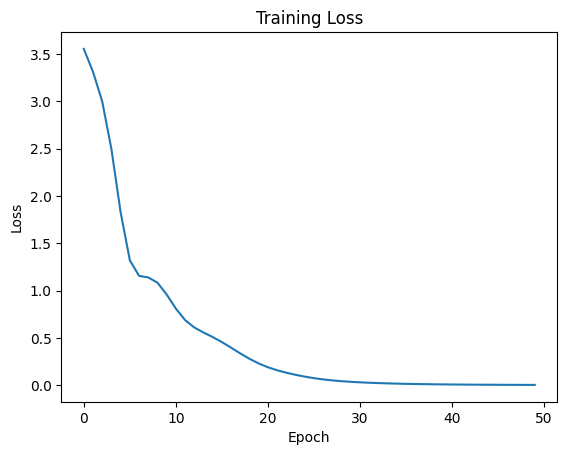

In [8]:
import matplotlib.pyplot as plt

plt.plot(loss_list)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [9]:
inv_vocab = {v:k for k,v in vocab.items()}

def generate_summary(model, sentence):
    model.eval()
    
    x = torch.tensor([encode(sentence, vocab)])
    
    with torch.no_grad():
        output = model(x)
        predicted = torch.argmax(output, dim=2)
    
    words = [inv_vocab[idx.item()] for idx in predicted[0]]
    
    return " ".join(words)

In [10]:
test_doc = "Machine learning uses models and algorithms"

print("Input:", test_doc)
print("Generated Summary:", generate_summary(model, test_doc))

Input: Machine learning uses models and algorithms
Generated Summary: ml trains <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
